# Importing Relevant Libraries

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Importing the dataset and understanding it 

In [12]:
df_init = pd.read_csv("Advertising.csv")
df_init.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Checking for missing values and duplicates

In [14]:
df_init.isna().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [26]:
df_init.duplicated().sum()

0

Key Insights
- There are no missing values and neither are there duplicates.

In [30]:
df_init.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [44]:
df_init.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [54]:
df = df_init[["TV", "Radio", "Newspaper", "Sales"]].copy()

In [56]:
df.shape

(200, 4)

## Getting Descriptive Statistics 

In [63]:
df.describe(include="all")

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


Key Insights
- The counts are consistent with no missing values.
- For the TV:
    - 147.04 is spent via TV advertisement if you pick an advert at random.
- Radio:
    - 23.26 is spent via Radio advertisement if you pick an advert at random.
- Newspaper:
    - 14.02 is spent via Newspaper advertisement if you pick an advert at random.

- People spend more on Television advertisements on average as compared to Radio and Newspapers.
- The distributions of each advertisement are approximately normal given the closeness of the means and the respective medians

## Plotting pairplots 

<Figure size 1200x800 with 0 Axes>

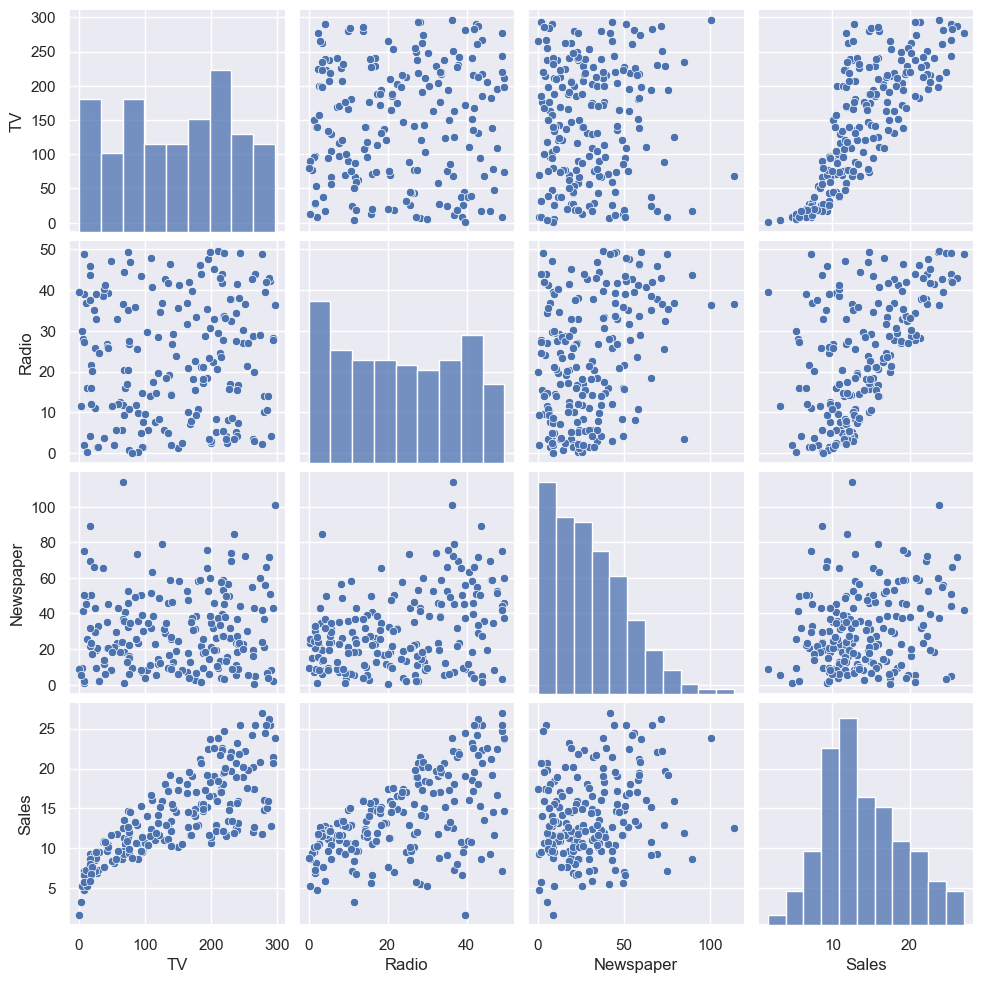

In [84]:
plt.figure(figsize=(12,8))
sns.pairplot(df)
plt.show()

Key insights
- There is a positive linear relationship between sales and TV, Radio, and Newspaper advertisement.
- The more the TV adverts, the more the sales. This is the same for Radio and Newspaper adverts.
- The Radio, Newspapers and TV sales have an inconsistent variance forming funnels.

## Scatter plots

### Scatter Plot for sales vs TV, Radio, and Newspaper adverts 

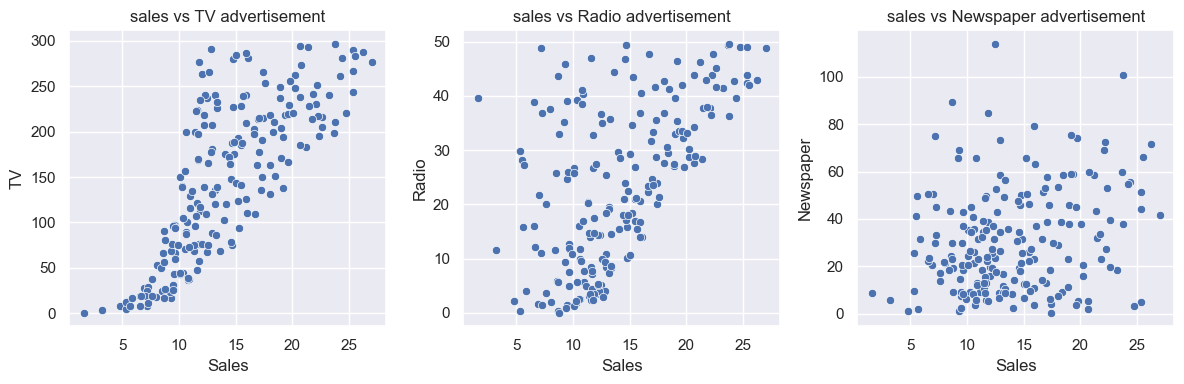

In [127]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

sns.scatterplot(data=df, x="Sales", y="TV", ax=axes[0])
axes[0].set_title("sales vs TV advertisement")

sns.scatterplot(data=df, x="Sales", y="Radio", ax=axes[1])
axes[1].set_title("sales vs Radio advertisement")

sns.scatterplot(data=df, x="Sales", y="Newspaper")
axes[2].set_title("sales vs Newspaper advertisement")

plt.tight_layout()
plt.show()

## Heatmap

In [123]:
cor_matrix = df.corr()

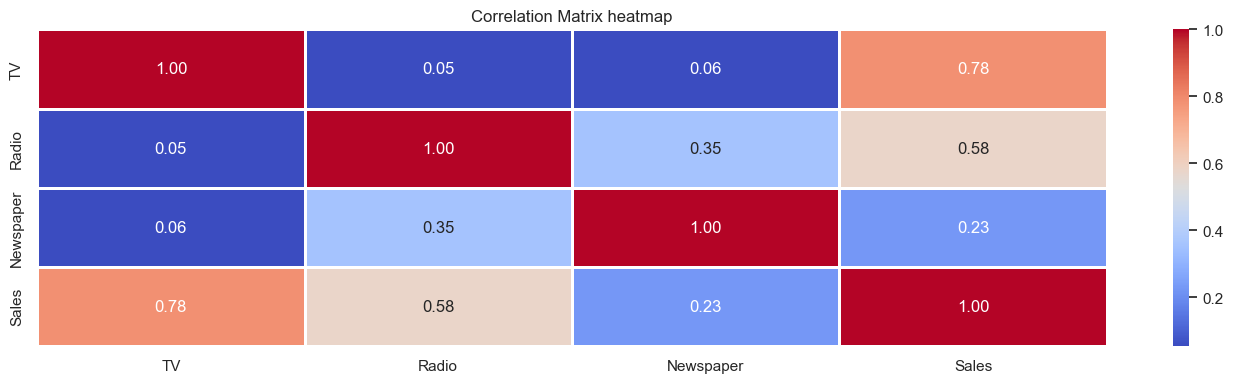

In [139]:
plt.figure(figsize=(14,4))
sns.heatmap(
    cor_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidth=1,
    cbar=True
)
plt.title("Correlation Matrix heatmap")
plt.tight_layout()
plt.show()

# Fitting the linear model

## 80/20 split

In [149]:
X = df.drop(columns=["Sales"])
y = df["Sales"]

In [155]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=256
)

lr = LinearRegression()
lr = lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [161]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

In [163]:
print(f"R_squared : {lr_r2:.4f}")
print(f"RMSE : {lr_rmse:.4f}")
print(f"MAE : {lr_mae:.4f}")

R_squared : 0.8460
RMSE : 1.7679
MAE : 1.2993


# Fitting the Random Forest Regressor

In [176]:
rf = RandomForestRegressor(n_estimators=100, random_state=256)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [178]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

In [180]:
print(f"R_squared : {rf_r2:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"MAE : {rf_mae:.4f}")

R_squared : 0.9797
RMSE : 0.6426
MAE : 0.4808
